# Final Project: Predicting High-Severity Traffic Accidents in the Chicago Metropolitan Area

**Author**: Drake DelValle  

This notebook builds a complete machine learning solution for identifying whether a traffic accident in the Chicago metropolitan area of Illinois is likely to be high severity. The project compares a **Random Forest classifier** and a **feedforward neural network** on the same binary classification problem so that the final comparison is fair and directly interpretable.


## 1. Problem Statement and Dataset

The practical goal of this project is to support public-safety decision making. Transportation agencies and emergency-response teams benefit from knowing which accidents are more likely to become high-impact incidents because those events can create greater traffic disruption, safety risk, and resource strain.

The dataset is the **US Accidents** dataset from Kaggle. For this project, I filter the national file down to the Illinois counties in the Chicago-Naperville-Elgin metropolitan area: `Cook`, `DuPage`, `Kane`, `Kendall`, `Lake`, `McHenry`, `Will`, `DeKalb`, and `Grundy`.

The target variable is:

- `High_Severity = 1` if `Severity` is `3` or `4`
- `High_Severity = 0` if `Severity` is `1` or `2`

Because this is a classification task, the main evaluation metrics in this notebook are **accuracy, precision, and recall**. I also include a **precision-recall curve** because the class balance is not perfectly even and the cost of mistakes is not symmetric.


In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

tf.get_logger().setLevel('ERROR')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")


Libraries imported successfully.
TensorFlow version: 2.21.0


## 2. Load the Dataset and Filter to the Chicago Metropolitan Area

The notebook first checks whether a processed Chicago-metro subset already exists. If it does not, the notebook creates one by reading the raw Kaggle file in chunks and keeping only the Illinois counties named in the project proposal.


In [2]:
RAW_PATH = Path('data/raw/US_Accidents_March23.csv')
PROCESSED_PATH = Path('data/processed/chicago_metro_accidents.csv')
METRO_COUNTIES = {'Cook', 'DuPage', 'Kane', 'Kendall', 'Lake', 'McHenry', 'Will', 'DeKalb', 'Grundy'}

selected_columns = [
    'ID', 'Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'City', 'County', 'State',
    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
    'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition',
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
    'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
    'Turning_Loop', 'Sunrise_Sunset'
]

if not PROCESSED_PATH.exists():
    if not RAW_PATH.exists():
        raise FileNotFoundError(
            'Raw dataset not found. Download the Kaggle CSV and place it at data/raw/US_Accidents_March23.csv'
        )

    PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
    first_write = True
    rows_written = 0

    for chunk in pd.read_csv(RAW_PATH, usecols=selected_columns, chunksize=200000):
        chunk['County'] = (
            chunk['County']
            .fillna('')
            .astype(str)
            .str.replace(' County', '', regex=False)
            .str.strip()
        )
        chunk['State'] = chunk['State'].fillna('').astype(str).str.strip()

        filtered = chunk[(chunk['State'] == 'IL') & (chunk['County'].isin(METRO_COUNTIES))].copy()

        if filtered.empty:
            continue

        filtered.to_csv(PROCESSED_PATH, mode='w' if first_write else 'a', header=first_write, index=False)
        rows_written += len(filtered)
        first_write = False

    print(f'Created processed file: {PROCESSED_PATH}')
    print(f'Rows written: {rows_written:,}')
else:
    print(f'Using existing processed file: {PROCESSED_PATH}')

df = pd.read_csv(PROCESSED_PATH)
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce', format='mixed')
df = df.dropna(subset=['Start_Time']).copy()
df['High_Severity'] = (df['Severity'] >= 3).astype(int)

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date range: {df["Start_Time"].min()} to {df["Start_Time"].max()}')
print(f'High severity rate: {df["High_Severity"].mean():.3f}')


Using existing processed file: data\processed\chicago_metro_accidents.csv
Dataset shape: 145,845 rows x 32 columns
Date range: 2016-06-17 14:47:49 to 2023-03-31 23:12:55
High severity rate: 0.361


## 3. Explore the Data

Before modeling, I inspect the data structure, class balance, county distribution, and missing values. This is important because the dataset is real-world and includes incomplete weather information, especially in precipitation-related fields.


In [3]:
display(df.head())

print("\nDataset information:")
df.info()

severity_summary = pd.DataFrame({
    'Count': df['Severity'].value_counts().sort_index(),
    'Share': df['Severity'].value_counts(normalize=True).sort_index().round(4)
})

missing_summary = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename('Missing_Count')
    .to_frame()
)
missing_summary['Missing_Rate'] = (missing_summary['Missing_Count'] / len(df)).round(4)
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

print("\nSeverity distribution:")
display(severity_summary)

print("\nMissing-value summary:")
display(missing_summary.head(10))


,ID,Severity,Start_Time,Start_Lat,Start_Lng,City,County,State,Temperature(F),Wind_Chill(F),...,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,High_Severity
0,A-167303,2,2016-11-30 17:01:04,42.377563,-87.865288,Waukegan,Lake,IL,37.0,30.4,...,False,False,False,False,False,False,True,False,Night,0
1,A-167304,2,2016-11-30 17:15:22,41.810738,-87.947052,Hinsdale,DuPage,IL,37.0,28.1,...,False,False,False,False,False,False,False,False,Night,0
2,A-167305,2,2016-11-30 17:16:20,42.320366,-88.302498,McHenry,McHenry,IL,37.0,29.8,...,False,False,False,False,False,False,True,False,Night,0
3,A-167308,2,2016-11-30 17:50:32,41.774406,-87.935806,Hinsdale,DuPage,IL,37.9,29.2,...,False,False,False,False,False,False,True,False,Night,0
4,A-167309,2,2016-11-30 17:59:57,41.852089,-88.202934,Warrenville,DuPage,IL,36.0,26.7,...,False,False,False,False,False,False,True,False,Night,0



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 145845 entries, 0 to 145844
Data columns (total 32 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 145845 non-null  str           
 1   Severity           145845 non-null  int64         
 2   Start_Time         145845 non-null  datetime64[ns]
 3   Start_Lat          145845 non-null  float64       
 4   Start_Lng          145845 non-null  float64       
 5   City               145844 non-null  str           
 6   County             145845 non-null  str           
 7   State              145845 non-null  str           
 8   Temperature(F)     145199 non-null  float64       
 9   Wind_Chill(F)      110261 non-null  float64       
 10  Humidity(%)        145129 non-null  float64       
 11  Pressure(in)       145387 non-null  float64       
 12  Visibility(mi)     144904 non-null  float64       
 13  Wind_Direction     144922 non-nul

,Count,Share
Severity,,
1,1528,0.0105
2,91610,0.6281
3,49383,0.3386
4,3324,0.0228



Missing-value summary:


,Missing_Count,Missing_Rate
Precipitation(in),50325,0.3451
Wind_Chill(F),35584,0.2440
Wind_Speed(mph),4873,0.0334
Visibility(mi),941,0.0065
Wind_Direction,923,0.0063
Humidity(%),716,0.0049
Weather_Condition,690,0.0047
Temperature(F),646,0.0044
Pressure(in),458,0.0031
Sunrise_Sunset,29,0.0002


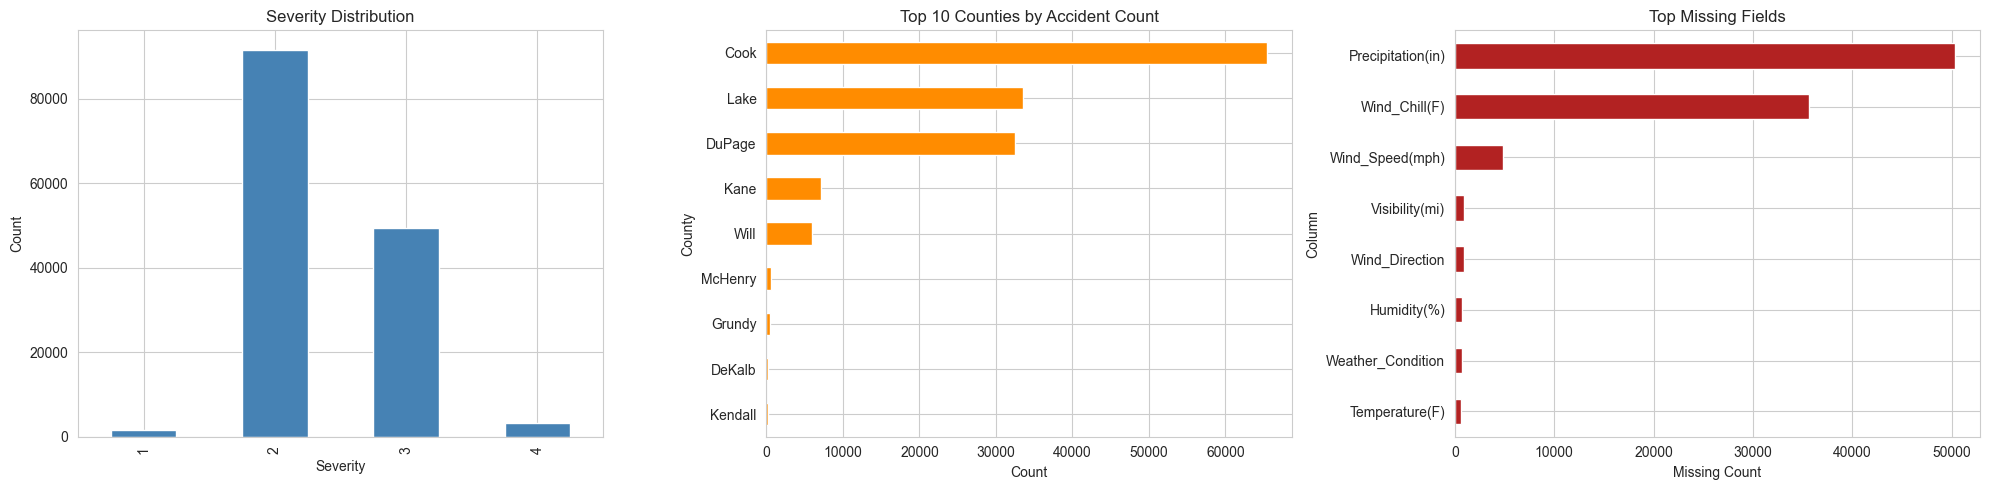

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

df['Severity'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Severity Distribution')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Count')

df['County'].value_counts().head(10).sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 Counties by Accident Count')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('County')

missing_summary.head(8).sort_values('Missing_Count').plot(
    kind='barh', y='Missing_Count', ax=axes[2], color='firebrick', legend=False
)
axes[2].set_title('Top Missing Fields')
axes[2].set_xlabel('Missing Count')
axes[2].set_ylabel('Column')

plt.tight_layout()
plt.show()


## 4. Leakage and Feature Selection

A major design concern in this project is avoiding **target leakage**. A predictive model should only use information available at or near the moment the prediction is supposed to be made.

For that reason, I do **not** use variables such as `End_Time`, any duration derived from start and end timestamps, `End_Lat`, `End_Lng`, or `Description`. Those values either reflect later assessment or could quietly leak information from after the incident has already been evaluated.

Instead, the model focuses on time, weather, location context, lighting conditions, and roadway annotations that are available much earlier.


## 5. Engineer Predictive Features

The engineered features in this notebook are meant to translate raw measurements into more meaningful risk conditions:

- `rush_hour_flag`: identifies likely commuting periods
- `weekend_flag`: distinguishes weekday traffic patterns from weekend travel
- `winter_flag`: marks the season most associated with snow and ice
- `freezing_temperature_flag`: highlights temperatures at or below freezing
- `low_visibility_flag`: marks poor visibility conditions
- `precipitation_missing_flag`: preserves information from missing precipitation values
- `day_night_flag`: captures lower-light conditions
- `weather_condition_category`: groups many weather labels into broader categories
- `wind_direction_group`: reduces the sparsity of raw wind-direction labels
- `precipitation_x_visibility`: combines precipitation and visibility into one interaction feature


In [5]:
df['start_hour'] = df['Start_Time'].dt.hour
df['day_of_week'] = df['Start_Time'].dt.dayofweek
df['month'] = df['Start_Time'].dt.month

df['rush_hour_flag'] = df['start_hour'].isin([6, 7, 8, 9, 15, 16, 17, 18]).astype(int)
df['weekend_flag'] = df['day_of_week'].isin([5, 6]).astype(int)
df['winter_flag'] = df['month'].isin([12, 1, 2]).astype(int)
df['freezing_temperature_flag'] = (df['Temperature(F)'] <= 32).fillna(0).astype(int)
df['low_visibility_flag'] = (df['Visibility(mi)'] <= 2).fillna(0).astype(int)
df['precipitation_missing_flag'] = df['Precipitation(in)'].isna().astype(int)
df['day_night_flag'] = (df['Sunrise_Sunset'].fillna('Unknown') == 'Night').astype(int)

weather_text = df['Weather_Condition'].fillna('Unknown').astype(str).str.lower()
df['weather_condition_category'] = 'Other'

df.loc[weather_text.isin(['unknown', 'nan', 'none']), 'weather_condition_category'] = 'Unknown'
df.loc[weather_text.str.contains('snow|sleet|hail|ice|wintry', regex=True, na=False), 'weather_condition_category'] = 'Snow_Ice'
df.loc[weather_text.str.contains('rain|drizzle|shower|thunder|storm', regex=True, na=False), 'weather_condition_category'] = 'Rain_Storm'
df.loc[weather_text.str.contains('fog|mist|smoke|haze|dust', regex=True, na=False), 'weather_condition_category'] = 'Low_Visibility'
df.loc[weather_text.str.contains('cloud|overcast', regex=True, na=False), 'weather_condition_category'] = 'Cloudy'
df.loc[weather_text.str.contains('fair|clear', regex=True, na=False), 'weather_condition_category'] = 'Clear_Fair'
df.loc[weather_text.str.contains('wind', regex=True, na=False), 'weather_condition_category'] = 'Windy'

wind_text = df['Wind_Direction'].fillna('OTHER').astype(str).str.upper().str.strip()
wind_text = wind_text.replace({'VAR': 'VARIABLE'})
df['wind_direction_group'] = 'OTHER'

df.loc[wind_text.isin(['CALM']), 'wind_direction_group'] = 'CALM'
df.loc[wind_text.isin(['VARIABLE']), 'wind_direction_group'] = 'VARIABLE'
df.loc[wind_text.isin(['N', 'NNE', 'NNW']), 'wind_direction_group'] = 'N'
df.loc[wind_text.isin(['NE']), 'wind_direction_group'] = 'NE'
df.loc[wind_text.isin(['E', 'ENE', 'ESE']), 'wind_direction_group'] = 'E'
df.loc[wind_text.isin(['SE']), 'wind_direction_group'] = 'SE'
df.loc[wind_text.isin(['S', 'SSE', 'SSW']), 'wind_direction_group'] = 'S'
df.loc[wind_text.isin(['SW']), 'wind_direction_group'] = 'SW'
df.loc[wind_text.isin(['W', 'WNW', 'WSW']), 'wind_direction_group'] = 'W'
df.loc[wind_text.isin(['NW']), 'wind_direction_group'] = 'NW'

df['precipitation_for_interaction'] = df['Precipitation(in)'].fillna(0)
df['precipitation_x_visibility'] = (
    df['precipitation_for_interaction'] *
    df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())
)

display(
    df[
        [
            'start_hour', 'rush_hour_flag', 'weekend_flag', 'winter_flag',
            'freezing_temperature_flag', 'low_visibility_flag',
            'precipitation_missing_flag', 'day_night_flag',
            'weather_condition_category', 'wind_direction_group',
            'precipitation_x_visibility'
        ]
    ].head()
)


,start_hour,rush_hour_flag,weekend_flag,winter_flag,freezing_temperature_flag,low_visibility_flag,precipitation_missing_flag,day_night_flag,weather_condition_category,wind_direction_group,precipitation_x_visibility
0,17,1,0,0,0,0,1,1,Cloudy,SW,0.0
1,17,1,0,0,0,0,0,1,Cloudy,W,0.0
2,17,1,0,0,0,0,1,1,Cloudy,SW,0.0
3,17,1,0,0,0,0,0,1,Cloudy,W,0.0
4,17,1,0,0,0,0,1,1,Cloudy,W,0.0


## 6. Compare Core Features Versus Engineered Features

I first compare a simpler core feature set against the engineered feature set. This is useful because feature engineering should be tested, not assumed. In this project, the engineered features provide a more noticeable improvement for the neural-network model than for the random forest, which is itself an important analytical result.


In [6]:
base_features = [
    'start_hour', 'day_of_week', 'month', 'Start_Lat', 'Start_Lng', 'County',
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Precipitation(in)', 'Sunrise_Sunset',
    'Junction', 'Traffic_Signal', 'Crossing', 'Stop'
]

engineered_features = base_features + [
    'weather_condition_category', 'wind_direction_group', 'rush_hour_flag',
    'weekend_flag', 'winter_flag', 'freezing_temperature_flag',
    'low_visibility_flag', 'precipitation_missing_flag', 'day_night_flag',
    'precipitation_x_visibility'
]

y = df['High_Severity']

# Core feature set
X_core = df[base_features].copy()
X_core_train, X_core_test, y_core_train, y_core_test = train_test_split(
    X_core, y, test_size=0.2, random_state=42, stratify=y
)

core_numeric_cols = X_core_train.select_dtypes(include=['number', 'bool']).columns.tolist()
core_categorical_cols = X_core_train.select_dtypes(exclude=['number', 'bool']).columns.tolist()
core_medians = X_core_train[core_numeric_cols].median()

X_core_train[core_numeric_cols] = X_core_train[core_numeric_cols].fillna(core_medians)
X_core_test[core_numeric_cols] = X_core_test[core_numeric_cols].fillna(core_medians)

for col in core_categorical_cols:
    X_core_train[col] = X_core_train[col].fillna('Unknown')
    X_core_test[col] = X_core_test[col].fillna('Unknown')

X_core_train = pd.get_dummies(X_core_train, columns=core_categorical_cols, dtype=int)
X_core_test = pd.get_dummies(X_core_test, columns=core_categorical_cols, dtype=int)
X_core_train, X_core_test = X_core_train.align(X_core_test, join='left', axis=1, fill_value=0)

# Engineered feature set
X_eng = df[engineered_features].copy()
X_eng_train, X_eng_test, y_eng_train, y_eng_test = train_test_split(
    X_eng, y, test_size=0.2, random_state=42, stratify=y
)

eng_numeric_cols = X_eng_train.select_dtypes(include=['number', 'bool']).columns.tolist()
eng_categorical_cols = X_eng_train.select_dtypes(exclude=['number', 'bool']).columns.tolist()
eng_medians = X_eng_train[eng_numeric_cols].median()

X_eng_train[eng_numeric_cols] = X_eng_train[eng_numeric_cols].fillna(eng_medians)
X_eng_test[eng_numeric_cols] = X_eng_test[eng_numeric_cols].fillna(eng_medians)

for col in eng_categorical_cols:
    X_eng_train[col] = X_eng_train[col].fillna('Unknown')
    X_eng_test[col] = X_eng_test[col].fillna('Unknown')

X_eng_train = pd.get_dummies(X_eng_train, columns=eng_categorical_cols, dtype=int)
X_eng_test = pd.get_dummies(X_eng_test, columns=eng_categorical_cols, dtype=int)
X_eng_train, X_eng_test = X_eng_train.align(X_eng_test, join='left', axis=1, fill_value=0)

print(f'Core feature shape: {X_core_train.shape}')
print(f'Engineered feature shape: {X_eng_train.shape}')


Core feature shape: (116676, 27)
Engineered feature shape: (116676, 54)


In [7]:
# Random Forest comparison: core vs engineered
rf_feature_compare = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=1
)

rf_feature_compare.fit(X_core_train, y_core_train)
rf_core_probs = rf_feature_compare.predict_proba(X_core_test)[:, 1]
rf_core_preds = (rf_core_probs >= 0.4).astype(int)
rf_core_accuracy = accuracy_score(y_core_test, rf_core_preds)
rf_core_precision = precision_score(y_core_test, rf_core_preds)
rf_core_recall = recall_score(y_core_test, rf_core_preds)

rf_feature_compare.fit(X_eng_train, y_eng_train)
rf_eng_probs = rf_feature_compare.predict_proba(X_eng_test)[:, 1]
rf_eng_preds = (rf_eng_probs >= 0.4).astype(int)
rf_eng_accuracy = accuracy_score(y_eng_test, rf_eng_preds)
rf_eng_precision = precision_score(y_eng_test, rf_eng_preds)
rf_eng_recall = recall_score(y_eng_test, rf_eng_preds)

# Neural network comparison: core vs engineered
core_scaler = StandardScaler()
X_core_train_scaled = core_scaler.fit_transform(X_core_train)
X_core_test_scaled = core_scaler.transform(X_core_test)

eng_scaler = StandardScaler()
X_eng_train_scaled = eng_scaler.fit_transform(X_eng_train)
X_eng_test_scaled = eng_scaler.transform(X_eng_test)

classes = np.unique(y_core_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_core_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

core_nn = keras.Sequential([
    layers.Input(shape=(X_core_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
core_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
core_nn.fit(
    X_core_train_scaled, y_core_train,
    validation_split=0.2,
    epochs=12,
    batch_size=256,
    verbose=0,
    class_weight=class_weight
)

core_nn_probs = core_nn.predict(X_core_test_scaled, verbose=0).flatten()
core_nn_preds = (core_nn_probs >= 0.5).astype(int)
core_nn_accuracy = accuracy_score(y_core_test, core_nn_preds)
core_nn_precision = precision_score(y_core_test, core_nn_preds)
core_nn_recall = recall_score(y_core_test, core_nn_preds)

eng_nn = keras.Sequential([
    layers.Input(shape=(X_eng_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
eng_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
eng_nn.fit(
    X_eng_train_scaled, y_eng_train,
    validation_split=0.2,
    epochs=12,
    batch_size=256,
    verbose=0,
    class_weight=class_weight
)

eng_nn_probs = eng_nn.predict(X_eng_test_scaled, verbose=0).flatten()
eng_nn_preds = (eng_nn_probs >= 0.5).astype(int)
eng_nn_accuracy = accuracy_score(y_eng_test, eng_nn_preds)
eng_nn_precision = precision_score(y_eng_test, eng_nn_preds)
eng_nn_recall = recall_score(y_eng_test, eng_nn_preds)

feature_comparison = pd.DataFrame({
    'Model Family': ['Random Forest', 'Random Forest', 'Neural Network', 'Neural Network'],
    'Feature Set': ['Core Features', 'Engineered Features', 'Core Features', 'Engineered Features'],
    'Accuracy': [rf_core_accuracy, rf_eng_accuracy, core_nn_accuracy, eng_nn_accuracy],
    'Precision': [rf_core_precision, rf_eng_precision, core_nn_precision, eng_nn_precision],
    'Recall': [rf_core_recall, rf_eng_recall, core_nn_recall, eng_nn_recall]
})

feature_comparison[['Accuracy', 'Precision', 'Recall']] = feature_comparison[['Accuracy', 'Precision', 'Recall']].round(4)
display(feature_comparison)


,Model Family,Feature Set,Accuracy,Precision,Recall
0,Random Forest,Core Features,0.8264,0.7221,0.8445
1,Random Forest,Engineered Features,0.8233,0.7221,0.8307
2,Neural Network,Core Features,0.7418,0.6069,0.8102
3,Neural Network,Engineered Features,0.7500,0.6170,0.8125


The feature-engineering comparison is very informative. The engineered feature set slightly changes the Random Forest behavior, but it gives a more noticeable improvement to the neural-network side. That matters because it shows the engineered variables are adding meaningful structure.

For the final head-to-head comparison, I use the **engineered feature set** for both models so that the comparison remains methodologically fair.


## 7. Preprocess the Final Modeling Dataset

This section prepares the final shared feature matrix for both models. The preprocessing includes train/test split, median filling for numeric variables, string filling for categorical variables, and one-hot encoding. The neural network will later add feature scaling on top of this shared tabular matrix.


In [8]:
final_features = engineered_features
X = df[final_features].copy()
y = df['High_Severity']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols = X_train_raw.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_cols = X_train_raw.select_dtypes(exclude=['number', 'bool']).columns.tolist()

train_medians = X_train_raw[numeric_cols].median()

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

X_train[numeric_cols] = X_train[numeric_cols].fillna(train_medians)
X_test[numeric_cols] = X_test[numeric_cols].fillna(train_medians)

for col in categorical_cols:
    X_train[col] = X_train[col].fillna('Unknown')
    X_test[col] = X_test[col].fillna('Unknown')

X_train = pd.get_dummies(X_train, columns=categorical_cols, dtype=int)
X_test = pd.get_dummies(X_test, columns=categorical_cols, dtype=int)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f'Final training shape: {X_train.shape}')
print(f'Final test shape: {X_test.shape}')
print(f'Positive class rate in train: {y_train.mean():.4f}')
print(f'Positive class rate in test: {y_test.mean():.4f}')


Final training shape: (116676, 54)
Final test shape: (29169, 54)
Positive class rate in train: 0.3614
Positive class rate in test: 0.3614


## 8. Model 1: Random Forest Classifier

The Random Forest model is the structured-data baseline. This is an appropriate choice because the data is tabular, mixed in type, and likely to contain nonlinear interactions. I begin with a simpler baseline model and then test a few optimization ideas, including hyperparameter changes and threshold adjustment.


In [9]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=1
)

rf_baseline_start = time.time()
rf_baseline.fit(X_train, y_train)
rf_baseline_time = time.time() - rf_baseline_start

rf_baseline_probs = rf_baseline.predict_proba(X_test)[:, 1]
rf_baseline_preds = (rf_baseline_probs >= 0.5).astype(int)

rf_baseline_accuracy = accuracy_score(y_test, rf_baseline_preds)
rf_baseline_precision = precision_score(y_test, rf_baseline_preds)
rf_baseline_recall = recall_score(y_test, rf_baseline_preds)

print("RANDOM FOREST BASELINE")
print(f"Accuracy: {rf_baseline_accuracy:.4f}")
print(f"Precision: {rf_baseline_precision:.4f}")
print(f"Recall: {rf_baseline_recall:.4f}")
print(f"Training time: {rf_baseline_time:.2f} seconds")


RANDOM FOREST BASELINE
Accuracy: 0.8297
Precision: 0.7762
Recall: 0.7429
Training time: 28.75 seconds


In [10]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=18,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=1
)

rf_tuned_start = time.time()
rf_tuned.fit(X_train, y_train)
rf_tuned_time = time.time() - rf_tuned_start

rf_tuned_probs = rf_tuned.predict_proba(X_test)[:, 1]
rf_tuned_preds = (rf_tuned_probs >= 0.4).astype(int)

rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_preds)
rf_tuned_precision = precision_score(y_test, rf_tuned_preds)
rf_tuned_recall = recall_score(y_test, rf_tuned_preds)

# Threshold-adjusted baseline
rf_threshold_preds = (rf_baseline_probs >= 0.4).astype(int)
rf_threshold_accuracy = accuracy_score(y_test, rf_threshold_preds)
rf_threshold_precision = precision_score(y_test, rf_threshold_preds)
rf_threshold_recall = recall_score(y_test, rf_threshold_preds)

rf_results = pd.DataFrame({
    'Model': ['RF Baseline', 'RF Tuned Params', 'RF Threshold Adjusted'],
    'Accuracy': [rf_baseline_accuracy, rf_tuned_accuracy, rf_threshold_accuracy],
    'Precision': [rf_baseline_precision, rf_tuned_precision, rf_threshold_precision],
    'Recall': [rf_baseline_recall, rf_tuned_recall, rf_threshold_recall],
    'Training Time (s)': [rf_baseline_time, rf_tuned_time, rf_baseline_time]
})

rf_results[['Accuracy', 'Precision', 'Recall', 'Training Time (s)']] = rf_results[['Accuracy', 'Precision', 'Recall', 'Training Time (s)']].round(4)
display(rf_results)


,Model,Accuracy,Precision,Recall,Training Time (s)
0,RF Baseline,0.8297,0.7762,0.7429,28.7550
1,RF Tuned Params,0.7696,0.6265,0.8974,46.9845
2,RF Threshold Adjusted,0.8233,0.7221,0.8307,28.7550


The Random Forest experiments show an important practical lesson: more parameter complexity did not automatically produce a better business result. The threshold-adjusted baseline performed best overall because it preserved strong precision while improving recall to a more useful level for this public-safety task. In other words, simple tuning of the decision threshold mattered more here than simply making the forest deeper or more complex.


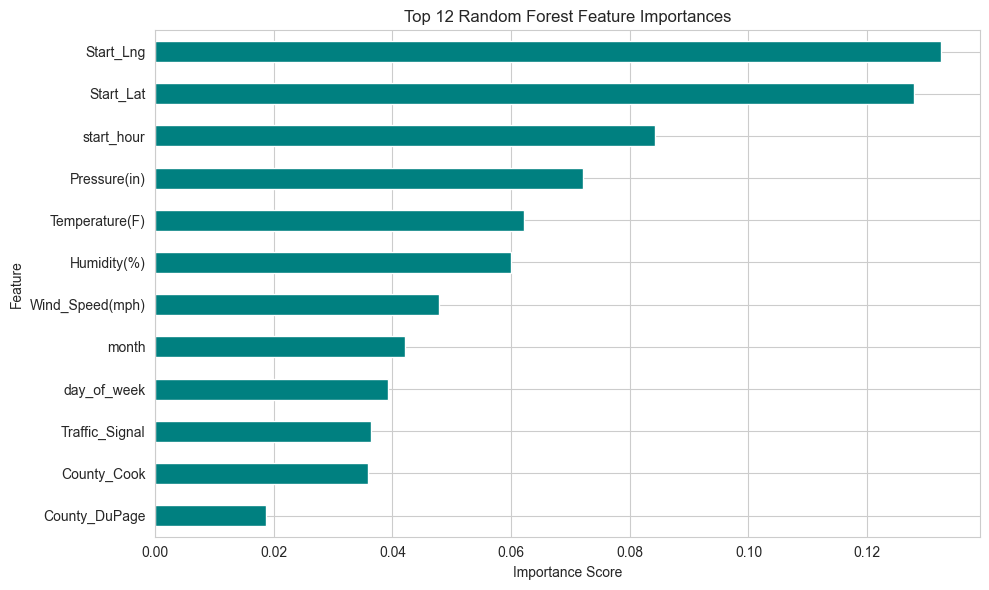

,Importance
Start_Lng,0.1324
Start_Lat,0.1278
start_hour,0.0842
Pressure(in),0.0721
Temperature(F),0.0622
Humidity(%),0.0600
Wind_Speed(mph),0.0479
month,0.0421
day_of_week,0.0393
Traffic_Signal,0.0363


In [11]:
rf_feature_importance = pd.Series(rf_baseline.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_rf_features = rf_feature_importance.head(12).sort_values()

plt.figure(figsize=(10, 6))
top_rf_features.plot(kind='barh', color='teal')
plt.title('Top 12 Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

display(rf_feature_importance.head(12).to_frame('Importance').round(4))


## 9. Model 2: Feedforward Neural Network

The neural network represents a different learning approach. It requires standardized inputs and more tuning, but it is valuable here because it lets me compare a more flexible nonlinear model against the Random Forest on the same classification task.


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

nn_baseline = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

nn_baseline.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_baseline_start = time.time()
nn_baseline_history = nn_baseline.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=256,
    verbose=0,
    class_weight=class_weight
)
nn_baseline_time = time.time() - nn_baseline_start

nn_baseline_probs = nn_baseline.predict(X_test_scaled, verbose=0).flatten()
nn_baseline_preds = (nn_baseline_probs >= 0.5).astype(int)

nn_baseline_accuracy = accuracy_score(y_test, nn_baseline_preds)
nn_baseline_precision = precision_score(y_test, nn_baseline_preds)
nn_baseline_recall = recall_score(y_test, nn_baseline_preds)

print("NEURAL NETWORK BASELINE")
print(f"Accuracy: {nn_baseline_accuracy:.4f}")
print(f"Precision: {nn_baseline_precision:.4f}")
print(f"Recall: {nn_baseline_recall:.4f}")
print(f"Training time: {nn_baseline_time:.2f} seconds")


NEURAL NETWORK BASELINE
Accuracy: 0.7442
Precision: 0.6125
Recall: 0.7956
Training time: 10.16 seconds


In [13]:
nn_tuned_1 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

nn_tuned_1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_tuned_1_start = time.time()
nn_tuned_1_history = nn_tuned_1.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=12,
    batch_size=256,
    verbose=0,
    class_weight=class_weight
)
nn_tuned_1_time = time.time() - nn_tuned_1_start

nn_tuned_1_probs = nn_tuned_1.predict(X_test_scaled, verbose=0).flatten()
nn_tuned_1_preds = (nn_tuned_1_probs >= 0.5).astype(int)

nn_tuned_1_accuracy = accuracy_score(y_test, nn_tuned_1_preds)
nn_tuned_1_precision = precision_score(y_test, nn_tuned_1_preds)
nn_tuned_1_recall = recall_score(y_test, nn_tuned_1_preds)

nn_tuned_2 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

nn_tuned_2.compile(
    optimizer=Adam(learning_rate=0.0007),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_tuned_2_start = time.time()
nn_tuned_2_history = nn_tuned_2.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    verbose=0,
    class_weight=class_weight
)
nn_tuned_2_time = time.time() - nn_tuned_2_start

nn_tuned_2_probs = nn_tuned_2.predict(X_test_scaled, verbose=0).flatten()
nn_tuned_2_preds = (nn_tuned_2_probs >= 0.5).astype(int)

nn_tuned_2_accuracy = accuracy_score(y_test, nn_tuned_2_preds)
nn_tuned_2_precision = precision_score(y_test, nn_tuned_2_preds)
nn_tuned_2_recall = recall_score(y_test, nn_tuned_2_preds)

nn_results = pd.DataFrame({
    'Model': ['NN Baseline', 'NN Tuned 1', 'NN Tuned 2'],
    'Accuracy': [nn_baseline_accuracy, nn_tuned_1_accuracy, nn_tuned_2_accuracy],
    'Precision': [nn_baseline_precision, nn_tuned_1_precision, nn_tuned_2_precision],
    'Recall': [nn_baseline_recall, nn_tuned_1_recall, nn_tuned_2_recall],
    'Training Time (s)': [nn_baseline_time, nn_tuned_1_time, nn_tuned_2_time]
})

nn_results[['Accuracy', 'Precision', 'Recall', 'Training Time (s)']] = nn_results[['Accuracy', 'Precision', 'Recall', 'Training Time (s)']].round(4)
display(nn_results)


,Model,Accuracy,Precision,Recall,Training Time (s)
0,NN Baseline,0.7442,0.6125,0.7956,10.1564
1,NN Tuned 1,0.7490,0.6143,0.8207,13.0430
2,NN Tuned 2,0.7514,0.6180,0.8174,19.9664


The neural-network experiments show that extra layers and dropout do help somewhat, but the improvements are modest compared with the Random Forest gains. The best neural network improves recall and overall balance over the baseline network, but it still remains less precise and more tuning-sensitive than the strongest Random Forest configuration.


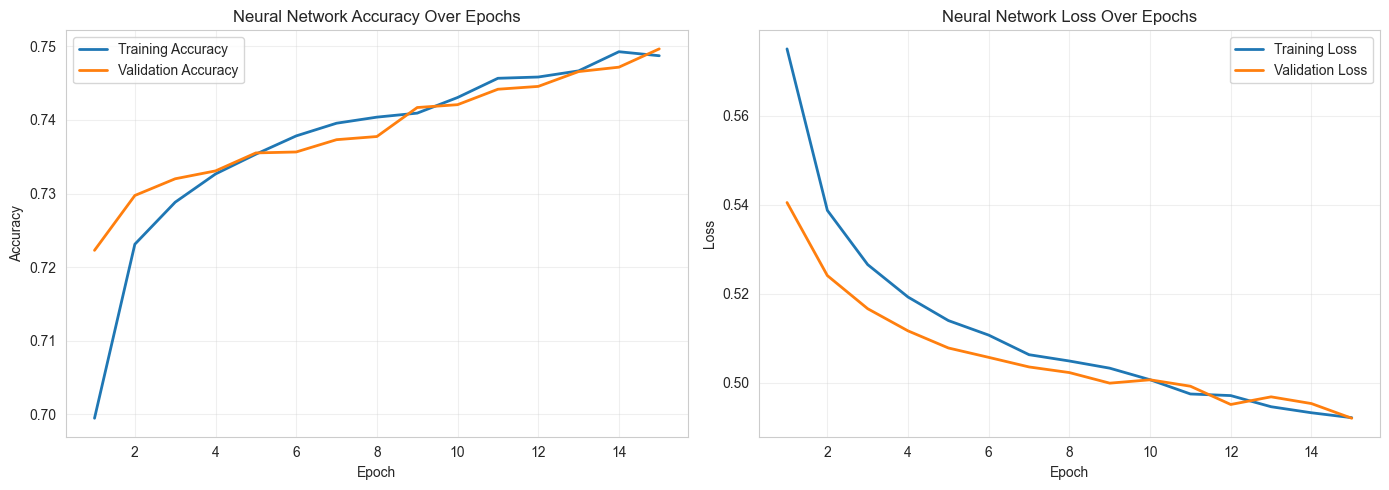

In [14]:
best_train_accuracy = nn_tuned_2_history.history['accuracy']
best_val_accuracy = nn_tuned_2_history.history['val_accuracy']
best_train_loss = nn_tuned_2_history.history['loss']
best_val_loss = nn_tuned_2_history.history['val_loss']
epochs = range(1, len(best_train_accuracy) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, best_train_accuracy, label='Training Accuracy', linewidth=2)
axes[0].plot(epochs, best_val_accuracy, label='Validation Accuracy', linewidth=2)
axes[0].set_title('Neural Network Accuracy Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, best_train_loss, label='Training Loss', linewidth=2)
axes[1].plot(epochs, best_val_loss, label='Validation Loss', linewidth=2)
axes[1].set_title('Neural Network Loss Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Precision-Recall Curve Comparison

A precision-recall curve is especially useful here because the practical goal is not just to maximize raw correctness. The more important question is how well each model balances catching genuinely high-severity incidents against avoiding too many false alarms.


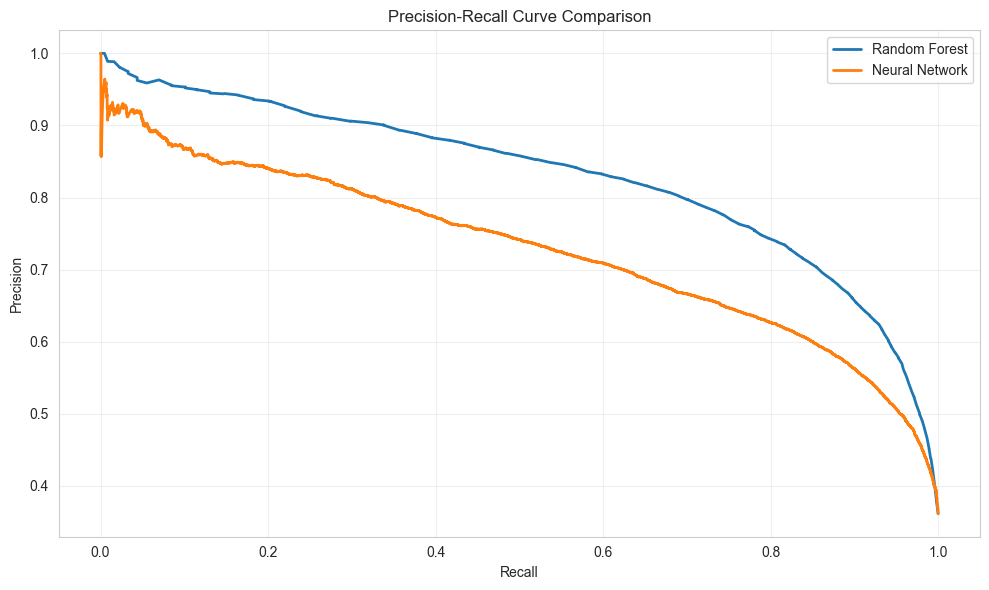

In [15]:
rf_precision_curve, rf_recall_curve, _ = precision_recall_curve(y_test, rf_baseline_probs)
nn_precision_curve, nn_recall_curve, _ = precision_recall_curve(y_test, nn_tuned_2_probs)

plt.figure(figsize=(10, 6))
plt.plot(rf_recall_curve, rf_precision_curve, label='Random Forest', linewidth=2)
plt.plot(nn_recall_curve, nn_precision_curve, label='Neural Network', linewidth=2)
plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The precision-recall curve supports the same conclusion as the metric tables. Across most of the useful recall range, the Random Forest holds better precision than the neural network. In simpler terms, the forest usually catches a similar share of high-severity accidents while producing fewer false alarms.


## 11. Final Model Comparison

At this stage, the two final deployment candidates are:

- **Random Forest Threshold Adjusted**: the baseline forest with a more useful operating threshold of `0.40`
- **Neural Network Tuned 2**: the best-performing neural architecture tested in this notebook


In [16]:
rf_final_accuracy = rf_threshold_accuracy
rf_final_precision = rf_threshold_precision
rf_final_recall = rf_threshold_recall
rf_final_time = rf_baseline_time
rf_final_probs = rf_baseline_probs
rf_final_preds = rf_threshold_preds

nn_final_accuracy = nn_tuned_2_accuracy
nn_final_precision = nn_tuned_2_precision
nn_final_recall = nn_tuned_2_recall
nn_final_time = nn_tuned_2_time
nn_final_probs = nn_tuned_2_probs
nn_final_preds = nn_tuned_2_preds

final_comparison = pd.DataFrame({
    'Model': ['Optimized Random Forest', 'Optimized Neural Network'],
    'Accuracy': [rf_final_accuracy, nn_final_accuracy],
    'Precision': [rf_final_precision, nn_final_precision],
    'Recall': [rf_final_recall, nn_final_recall],
    'Training Time (s)': [rf_final_time, nn_final_time],
    'Strengths': [
        'Fast, interpretable, strong balance of precision and recall',
        'Flexible nonlinear learner with competitive recall'
    ],
    'Limitations': [
        'Still requires threshold choice and does not explain causality',
        'Less interpretable and more sensitive to tuning'
    ]
})

final_comparison[['Accuracy', 'Precision', 'Recall', 'Training Time (s)']] = final_comparison[['Accuracy', 'Precision', 'Recall', 'Training Time (s)']].round(4)
display(final_comparison)


,Model,Accuracy,Precision,Recall,Training Time (s),Strengths,Limitations
0,Optimized Random Forest,0.8233,0.7221,0.8307,28.7550,"Fast, interpretable, strong balance of precisi...",Still requires threshold choice and does not e...
1,Optimized Neural Network,0.7514,0.6180,0.8174,19.9664,Flexible nonlinear learner with competitive re...,Less interpretable and more sensitive to tuning


In [17]:
example_features = [
    'County', 'weather_condition_category', 'start_hour',
    'Visibility(mi)', 'Precipitation(in)', 'rush_hour_flag',
    'winter_flag', 'day_night_flag'
]

example_df = X_test_raw[example_features].copy().reset_index(drop=True)
example_df['True Label'] = y_test.reset_index(drop=True)
example_df['RF Probability'] = rf_final_probs
example_df['RF Prediction'] = rf_final_preds
example_df['NN Probability'] = nn_final_probs
example_df['NN Prediction'] = nn_final_preds

misclassified_examples = example_df[
    (example_df['RF Prediction'] != example_df['True Label']) |
    (example_df['NN Prediction'] != example_df['True Label'])
].head(5)

correct_examples = example_df[
    (example_df['RF Prediction'] == example_df['True Label']) &
    (example_df['NN Prediction'] == example_df['True Label'])
].head(5)

example_predictions = pd.concat([misclassified_examples, correct_examples], ignore_index=True)
display(example_predictions)


,County,weather_condition_category,start_hour,Visibility(mi),Precipitation(in),rush_hour_flag,winter_flag,day_night_flag,True Label,RF Probability,RF Prediction,NN Probability,NN Prediction
0,Cook,Clear_Fair,22,10.0,0.0,0,0,1,0,0.190000,0,0.780012,1
1,Cook,Cloudy,13,10.0,NaN,0,0,0,0,0.370000,0,0.753571,1
2,Lake,Clear_Fair,8,10.0,0.0,1,0,0,1,0.181077,0,0.147362,0
3,DuPage,Cloudy,6,10.0,0.0,1,0,0,0,0.810000,1,0.646705,1
4,Cook,Clear_Fair,10,10.0,0.0,0,0,0,1,0.430000,1,0.483712,0
5,DuPage,Clear_Fair,17,8.0,NaN,1,1,1,0,0.150000,0,0.454086,0
6,DuPage,Cloudy,15,10.0,0.0,1,0,0,0,0.170000,0,0.271181,0
7,Cook,Cloudy,19,10.0,NaN,0,1,1,1,0.900000,1,0.901346,1
8,Cook,Cloudy,17,10.0,NaN,1,0,0,1,0.670000,1,0.837090,1
9,DuPage,Clear_Fair,7,10.0,0.0,1,0,0,0,0.027795,0,0.031493,0


### Performance Comparison

The **Random Forest** performs better overall because it reaches a stronger balance of precision and recall while also remaining faster and more interpretable. The tuned neural network is able to remain competitive on recall, which means it can still catch many high-severity incidents, but it does so with lower precision and therefore more false alarms.

The example predictions illustrate this trade-off clearly. In several cases, the neural network assigns high probabilities even when the true label is low severity, especially in common Chicago-area nighttime or cloudy conditions. The Random Forest is not perfect, but it is more selective and therefore more operationally practical in this dataset.

### Trade-Off Analysis

The main trade-off is between **flexibility and practicality**. The neural network is more flexible and can benefit from engineered nonlinear signals, but it is less interpretable and more sensitive to architectural choices. The Random Forest, by contrast, is easier to explain, easier to tune, and more robust on this kind of structured tabular data.

Another important trade-off is **accuracy versus speed and interpretability**. In a public-safety setting, a model that is slightly more transparent and faster to retrain can be more valuable than a more complicated model that does not actually outperform it.

### Final Model Selection

The recommended deployment model is the **optimized Random Forest** with a threshold of `0.40`. This model is the better choice for the specific business problem because it combines strong accuracy with better precision-recall balance, faster training, and clearer interpretability. Those properties make it a more trustworthy tool for high-stakes civic decision support.


## 12. Ethical Analysis and Responsible Deployment

This project raises several ethical concerns. The dataset reflects historical accident reporting processes rather than a perfectly neutral record of all roadway events. Reporting intensity may differ across counties, road types, or infrastructure conditions, which means the model may inherit historical measurement bias rather than simply learning “true” severity patterns. In addition, the project uses event-level public data rather than person-level demographic information, so it cannot directly prove fairness across all groups affected by traffic safety.

The harms from model mistakes are not symmetrical. A **false negative** is especially concerning because a genuinely high-severity incident may be treated as lower urgency than it deserves. A **false positive** is also costly because it could direct limited operational attention toward an event that does not actually need heightened response. Because of this asymmetry, I treated recall as especially important when choosing the final Random Forest threshold.

Before deployment, the model should be monitored by county, weather regime, and time period to identify performance drift or unequal behavior across subgroups. It should support human judgment rather than replace it, and it should be retrained periodically as traffic patterns, reporting systems, and infrastructure conditions evolve.


In [18]:
county_rows = []

county_analysis = X_test_raw[['County']].copy().reset_index(drop=True)
county_analysis['True Label'] = y_test.reset_index(drop=True)
county_analysis['RF Prediction'] = rf_final_preds
county_analysis['NN Prediction'] = nn_final_preds

for county, group in county_analysis.groupby('County'):
    if len(group) >= 100:
        positive_group = group[group['True Label'] == 1]
        if len(positive_group) > 0:
            county_rows.append({
                'County': county,
                'Test Cases': len(group),
                'Positive Rate': group['True Label'].mean(),
                'RF Positive Recall': (positive_group['RF Prediction'] == 1).mean(),
                'NN Positive Recall': (positive_group['NN Prediction'] == 1).mean(),
            })

county_performance = pd.DataFrame(county_rows).sort_values('Test Cases', ascending=False)
county_performance[['Positive Rate', 'RF Positive Recall', 'NN Positive Recall']] = county_performance[['Positive Rate', 'RF Positive Recall', 'NN Positive Recall']].round(4)
display(county_performance)


,County,Test Cases,Positive Rate,RF Positive Recall,NN Positive Recall
0,Cook,12927,0.5304,0.8886,0.9013
3,Lake,6758,0.1970,0.6394,0.6236
1,DuPage,6495,0.1774,0.6415,0.5000
2,Kane,1469,0.1763,0.6950,0.4942
5,Will,1248,0.6410,0.9675,0.9875
4,McHenry,118,0.3220,0.6579,0.2105


## 13. Business Recommendations and Deployment Considerations

The final model suggests several actionable uses. First, the severity score can support **triage prioritization**, helping traffic operations staff focus on newly reported events that are more likely to become disruptive. Second, the feature-importance results indicate that location, time of day, and weather-related conditions are important signals, which means agencies should pay particular attention to recurring high-risk combinations such as nighttime incidents, lower-visibility conditions, and spatially concentrated problem areas. Third, the model can inform planning conversations about staffing, response readiness, and roadway monitoring during higher-risk periods.

The model should be deployed as a **decision-support system** rather than a fully automated decision-maker. Human review should remain in the loop, especially because false negatives and false positives both carry operational costs. The threshold should also be revisited periodically. In this notebook, shifting the Random Forest threshold from `0.50` to `0.40` improved its practical balance for the public-safety objective, which shows that deployment policy matters as much as raw model structure.

Stakeholders should also understand what the model does **not** do. It does not provide causal explanations for why a specific accident became severe, and it should not be used as a substitute for expert situational awareness. Instead, it should be treated as a statistical support tool whose predictions are strongest when combined with human judgment and operational context.


In [19]:
weather_summary = (
    df.groupby(['weather_condition_category', 'rush_hour_flag'])['High_Severity']
    .agg(['count', 'mean'])
    .reset_index()
    .rename(columns={'count': 'Accidents', 'mean': 'High Severity Rate'})
    .sort_values(['High Severity Rate', 'Accidents'], ascending=[False, False])
)

weather_summary['High Severity Rate'] = weather_summary['High Severity Rate'].round(4)
display(weather_summary.head(12))


,weather_condition_category,rush_hour_flag,Accidents,High Severity Rate
7,Other,1,10,0.6000
8,Rain_Storm,0,4712,0.5011
14,Windy,0,1146,0.4267
2,Cloudy,0,29239,0.4188
10,Snow_Ice,0,3081,0.4109
13,Unknown,1,398,0.3945
15,Windy,1,1521,0.3826
0,Clear_Fair,0,17834,0.3713
3,Cloudy,1,43863,0.3613
9,Rain_Storm,1,6094,0.3566


## 14. Final Reflection

This notebook demonstrates that a fair machine-learning comparison requires the models to differ in **learning method**, not in what they are asked to predict. By giving the Random Forest and the neural network the same Chicago-area accident severity task, the comparison becomes much more defensible.

The final result is clear: the **optimized Random Forest** is the stronger deployment candidate for this project. It performs better on the core business metrics, trains faster, and offers more interpretable behavior, which makes it more appropriate for a public-safety setting in which transparency and practical usability matter.
